# Titanic Project with Keras and Deep Learning

## Binary Classification

The goal of this project is to build a **Deep Learning classification model with Keras** to predict whether a passenger survived the Titanic disaster.

The target variable is:

- `Survived = 0` → Did not survive
- `Survived = 1` → Survived

The project follows a simple Deep Learning workflow:

**Load Data → Explore Data → Prepare Data → Train/Test Split → Scale Data → Build Neural Network → Train → Evaluate → Predict**

In addition to numerical features, the model also uses categorical information such as **Sex** and **Embarked**, together with a simple engineered feature called **FamilySize**.

## 1. Import Libraries

In [30]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

## 2. Load Data

`ttrain.csv` contains the target column `Survived`

`ttest.csv` does not contain `Survived`. We will use it at the end to create predictions

In [31]:
df = pd.read_csv("ttrain.csv")
test_df = pd.read_csv("ttest.csv")

In [32]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [33]:
print("Train shape:", df.shape)
print("Test shape :", test_df.shape)

Train shape: (891, 12)
Test shape : (418, 11)


## 3. Data Control

In [34]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 118.9 KB


In [35]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

The main missing values are in **Age**, **Cabin** and a small number of **Embarked/Fare** values.

We will not use `Cabin` because it contains too many missing values.
For the variables we use, missing numerical values will be filled with the **median**, and `Embarked` with the most frequent value.

## 4. Data Visualization

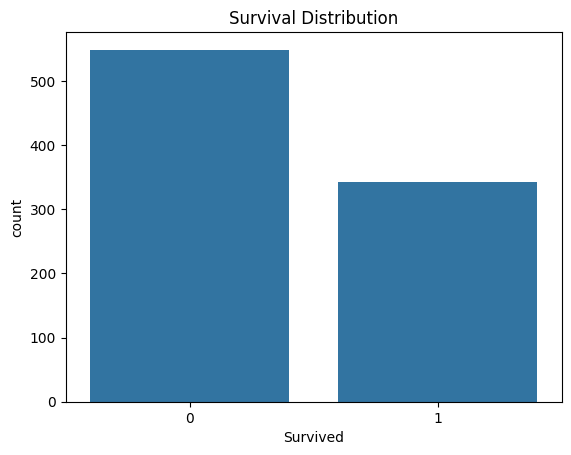

In [36]:
sns.countplot(data=df, x="Survived")
plt.title("Survival Distribution")
plt.show()

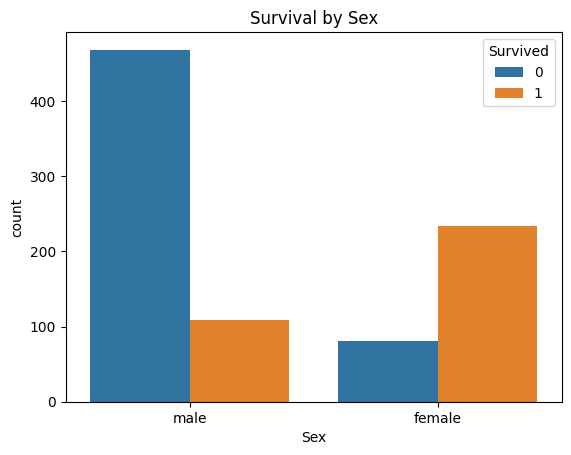

In [37]:
sns.countplot(data=df, x="Sex", hue="Survived")
plt.title("Survival by Sex")
plt.show()

## 5. Missing Values and Feature Engineering

The training data contains missing values mainly in **Age** and **Cabin**, while the test data also has missing values in **Age** and **Fare**.

We will not use `Cabin` because it contains too many missing values. Missing numerical values will be filled with the **median**, and `Embarked` with the most frequent value.

We also add one simple new feature:

`FamilySize = SibSp + Parch + 1`

This represents the total number of family members travelling together, including the passenger

In [38]:
age_median = df["Age"].median()
fare_median = df["Fare"].median()
embarked_mode = df["Embarked"].mode()[0]

for data in [df, test_df]:
    data["Age"] = data["Age"].fillna(age_median)
    data["Fare"] = data["Fare"].fillna(fare_median)
    data["Embarked"] = data["Embarked"].fillna(embarked_mode)
    data["FamilySize"] = data["SibSp"] + data["Parch"] + 1

In [39]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
FamilySize       0
dtype: int64

## 6. Feature Selection

We use:
- Passenger class
- Sex
- Age
- Number of siblings/spouses
- Number of parents/children
- Fare
- Port of embarkation
- Family size

`Name`, `Ticket`, `Cabin` and `PassengerId` are not used as model inputs in this simple version.

In [40]:
features = [
    "Pclass",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Embarked",
    "FamilySize"
]

x = df[features]
y = df["Survived"]

x_test_final = test_df[features]

## 7. Convert Categorical Data to Numbers

Deep Learning models need numerical inputs

We convert `Sex` and `Embarked` using `pd.get_dummies()`

In [41]:
x = pd.get_dummies(
    x,
    columns=["Sex", "Embarked"],
    drop_first=True,
    dtype=int
)

x_test_final = pd.get_dummies(
    x_test_final,
    columns=["Sex", "Embarked"],
    drop_first=True,
    dtype=int
)

# Make sure train and final test have exactly the same columns
x_test_final = x_test_final.reindex(columns=x.columns, fill_value=0)

x.head()

,Pclass,Age,SibSp,Parch,Fare,FamilySize,Sex_male,Embarked_Q,Embarked_S
0,3,22.0,1,0,7.2500,2,1,0,1
1,1,38.0,1,0,71.2833,2,0,0,0
2,3,26.0,0,0,7.9250,1,0,0,1
3,1,35.0,1,0,53.1000,2,0,0,1
4,3,35.0,0,0,8.0500,1,1,0,1


In [42]:
print("Model input columns:")
print(x.columns.tolist())
print("\nNumber of features:", x.shape[1])

Model input columns:
['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'Sex_male', 'Embarked_Q', 'Embarked_S']

Number of features: 9


## 8. Train / Test Split

We keep **20%** of the training data for testing the model.

`stratify=y` keeps the survival ratio similar in both train and test groups

In [43]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("x_train:", x_train.shape)
print("x_test :", x_test.shape)

x_train: (712, 9)
x_test : (179, 9)


## 9. Scale the Data

Scaling helps the neural network learn more efficiently because numerical variables such as `Age` and `Fare` have very different ranges.

In [44]:
scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)
x_test_final_scaled = scaler.transform(x_test_final)

## 10. Build the Deep Learning Model

This is a simple fully connected neural network.

- Hidden layers use **ReLU**
- Final layer uses **Sigmoid**
- Sigmoid is suitable because our answer is binary: `0` or `1`.

In [45]:
model = Sequential()

model.add(Input(shape=(x_train.shape[1],)))
model.add(Dense(32, activation="relu"))
model.add(Dense(16, activation="relu"))
model.add(Dense(8, activation="relu"))
model.add(Dense(1, activation="sigmoid"))

In [46]:
model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

In [47]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                      │ (None, 32)                  │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 8)                   │             136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 1)                   │               9 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 993 (3.88 KB)

 Trainable params: 993 (3.88 KB)

 Non-trainable params: 0 (0.00 B)

## 11. Train the Model

In [48]:
history = model.fit(
    x_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.20,
    verbose=1
)

Epoch 1/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.6292 - loss: 0.6561 - val_accuracy: 0.5944 - val_loss: 0.6423
Epoch 2/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6435 - loss: 0.6064 - val_accuracy: 0.5944 - val_loss: 0.6051
Epoch 3/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6130 - loss: 0.5832 - val_accuracy: 0.5944 - val_loss: 0.5788
Epoch 4/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6357 - loss: 0.5446 - val_accuracy: 0.5944 - val_loss: 0.5649
Epoch 5/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6491 - loss: 0.5206 - val_accuracy: 0.6154 - val_loss: 0.5570
Epoch 6/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6664 - loss: 0.5251 - val_accuracy: 0.6853 - val_loss: 0.5498
Epoch 7/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6986 - loss: 0.5642 - val_accuracy: 0.7552 - val_loss: 0.5443
Epoch 8/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7822 - loss: 0.5022 - val_accuracy: 0.7622 - val_loss

## 12. Model Performance

In [49]:
loss, accuracy = model.evaluate(x_test, y_test, verbose=0)

print("Test Loss    :", round(loss, 4))
print("Test Accuracy:", round(accuracy, 4))

Test Loss    : 0.5121
Test Accuracy: 0.7989


### Accuracy Graph

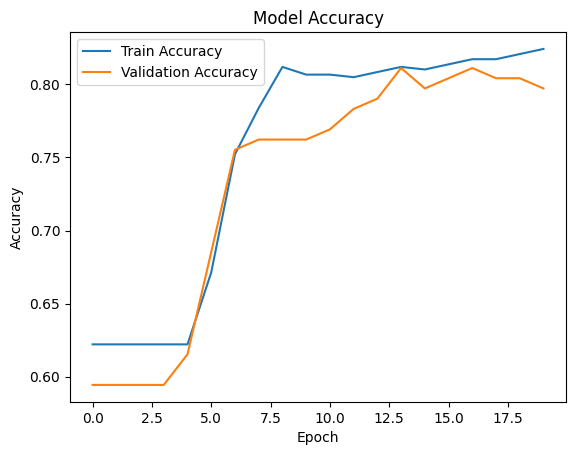

In [50]:
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

### Loss Graph

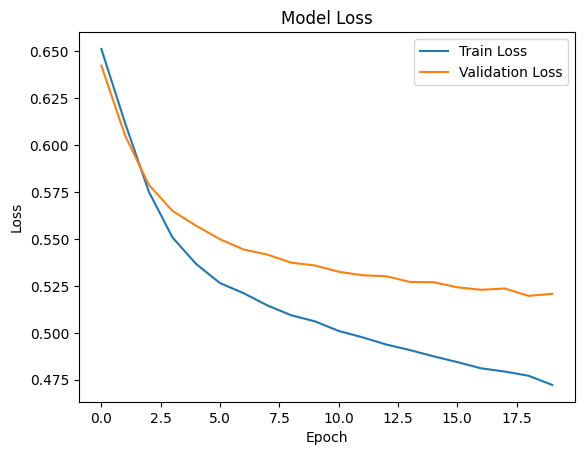

In [51]:
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

## 13. Predictions and Classification Metrics

The model returns probabilities between `0` and `1`

We use `0.5` as the classification threshold

In [52]:
pred_probability = model.predict(x_test, verbose=0).ravel()

prediction = (pred_probability >= 0.5).astype(int)

print("Accuracy:", round(accuracy_score(y_test, prediction), 4))
print()

print(classification_report(y_test, prediction))

Accuracy: 0.7989

              precision    recall  f1-score   support

           0       0.78      0.95      0.85       110
           1       0.87      0.57      0.68        69

    accuracy                           0.80       179
   macro avg       0.82      0.76      0.77       179
weighted avg       0.81      0.80      0.79       179



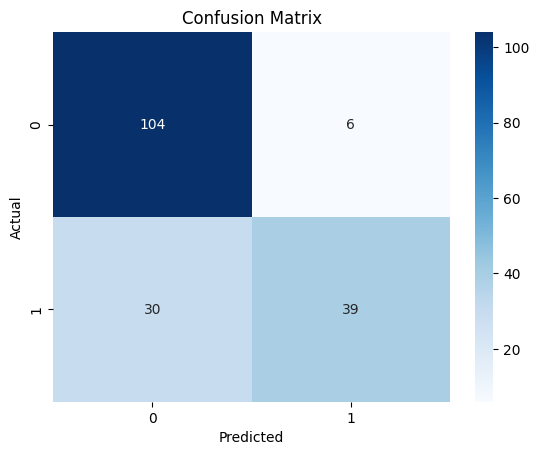

In [53]:
cm = confusion_matrix(y_test, prediction)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## 14. Predict the Real Titanic Test Data

Now we use the trained model on `ttest.csv`

Because this file has no `Survived` column, these predictions cannot be evaluated locally. They are prepared as a submission file

In [54]:
final_probability = model.predict(
    x_test_final_scaled,
    verbose=0
).ravel()

final_prediction = (final_probability >= 0.5).astype(int)

submission = pd.DataFrame({
    "PassengerId": test_df["PassengerId"],
    "Survived": final_prediction
})

submission.head()

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,0


In [55]:
submission.to_csv(
    "titanic_submission.csv",
    index=False
)

print("titanic_submission.csv created")
print("Rows:", len(submission))

titanic_submission.csv created
Rows: 418


## 15. Summary

In this project, a **Keras Deep Learning binary classification model** was developed to predict Titanic passenger survival.

The project included:

- Data exploration and missing value analysis
- Missing value handling
- Categorical data conversion with `pd.get_dummies()`
- Feature engineering with `FamilySize`
- Train/test split
- Feature scaling with `StandardScaler`
- A Keras `Sequential` neural network
- ReLU activation in the hidden layers
- Sigmoid activation in the output layer
- Binary crossentropy loss
- Model training for 20 epochs
- Accuracy and loss visualization
- Classification report
- Confusion matrix
- Prediction on the real Titanic test dataset
- Kaggle-style `titanic_submission.csv` creation
- Saving the trained Keras model

The final model achieved a **test accuracy of approximately 79.9%**.

The project demonstrates a complete and simple Deep Learning classification workflow, from data exploration and preparation to feature engineering, model training, evaluation, and final predictions.

### Optional: Save the Trained Model

The trained Keras model is saved so that it can be loaded and used later without training it again

In [59]:
model.save("titanic_deep_learning_model.keras")